<a href="https://colab.research.google.com/github/Tsanami/HSE_DL_2026/blob/HW4/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q -U bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.9 MB/s eta 0:00:00


In [ ]:
from transformers import AutoProcessor, AutoModelForCausalLM, BitsAndBytesConfig
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor
import torch
import gc
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from textwrap import fill
import transformers
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

In [ ]:
model_name = "Qwen/Qwen3-0.6B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    dtype=torch.float16,
    quantization_config=quantization_config
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
df = pd.read_csv('getoptimal.txt', sep ='|')
df = df.sample(frac=1).reset_index(drop=True)
df.columns = ['text', 'label']
texts, labels = df['text'].tolist(), df['label'].tolist()
df.head()

,text,label
0,"В ресторане кормят вкусно, порции огромные, но...",1
1,"Квартира после ремонта выглядит отлично, все с...",1
2,"В кафе порции огромные и дешево, но готовят та...",1
3,Мне повысили зарплату и дали отдельный кабинет...,0
4,"Куртка красивая и модная, но совсем не греет. ...",1


In [ ]:
num_layers = model.config.num_hidden_layers + 1
hidden_size = model.config.hidden_size

all_features = np.zeros((len(texts), num_layers, hidden_size))

In [ ]:
len(hidden_states), len(hidden_states[0]), len(hidden_states[0][0]), hidden_states[0][0].shape

(29, 1, 13, torch.Size([13, 1024]))

In [ ]:
num_layers = model.config.num_hidden_layers + 1
hidden_size = model.config.hidden_size

all_features = np.zeros((len(texts), num_layers, hidden_size))

model.eval()
with torch.no_grad():
    for i, text in enumerate(texts):
        inputs = tokenizer(text, return_tensors="pt").to(model.device)
        outputs = model(**inputs,
                        max_new_tokens=32768,
                        use_cache=True,
                        return_dict_in_generate=True,
                        output_hidden_states=True)

        hidden_states = outputs.hidden_states

        for l in range(num_layers):
            last_token_vector = hidden_states[l][0, -1, :].cpu().numpy()
            all_features[i, l, :] = last_token_vector

features_normal = all_features[np.array(labels) == 0]
features_anom = all_features[np.array(labels) == 1]

In [ ]:
epsilon = 1e-8

kl_scores = []
ldr_scores = []
entropy_scores = []

for l in range(num_layers):
    h_norm = features_normal[:, l, :]
    h_anom = features_anom[:, l, :]
    h_all = all_features[:, l, :]

    mu_norm = np.mean(h_norm, axis=0)
    var_norm = np.var(h_norm, axis=0) + epsilon

    mu_anom = np.mean(h_anom, axis=0)
    var_anom = np.var(h_anom, axis=0) + epsilon

    kl_d = 0.5 * (np.log(var_norm / var_anom) +
                  (var_anom + (mu_anom - mu_norm)**2) / var_norm - 1)
    kl_score = np.mean(kl_d)
    kl_scores.append(kl_score)

    ldr_d = ((mu_norm - mu_anom)**2) / (var_norm + var_anom + epsilon)
    ldr_score = np.mean(ldr_d)
    ldr_scores.append(ldr_score)

    B = 20
    entropy_d = []
    for d in range(hidden_size):
        counts, _ = np.histogram(h_all[:, d], bins=B, density=False)
        probs = counts / np.sum(counts)
        probs = probs[probs > 0]
        ent = -np.sum(probs * np.log2(probs))
        entropy_d.append(ent)

    entropy_score = np.mean(entropy_d)
    entropy_scores.append(entropy_score)

kl_scores = np.array(kl_scores)
ldr_scores = np.array(ldr_scores)
entropy_scores = np.array(entropy_scores)

In [ ]:
from scipy.stats import zscore
norm_kl = zscore(kl_scores)
norm_ldr = zscore(ldr_scores)
norm_entropy = zscore(entropy_scores)


S_l = norm_kl + norm_ldr + norm_entropy
optimal_layer = np.argmax(S_l)

k = 3
top_k_layers = np.sort(np.argpartition(S_l, -k)[-k:])

print(f"Топ 3 оптимальных слоя для задачи амбивалентности: {top_k_layers} из {num_layers - 1}")

Топ 3 оптимальных слоя для задачи амбивалентности: [ 1 16 17] из 28


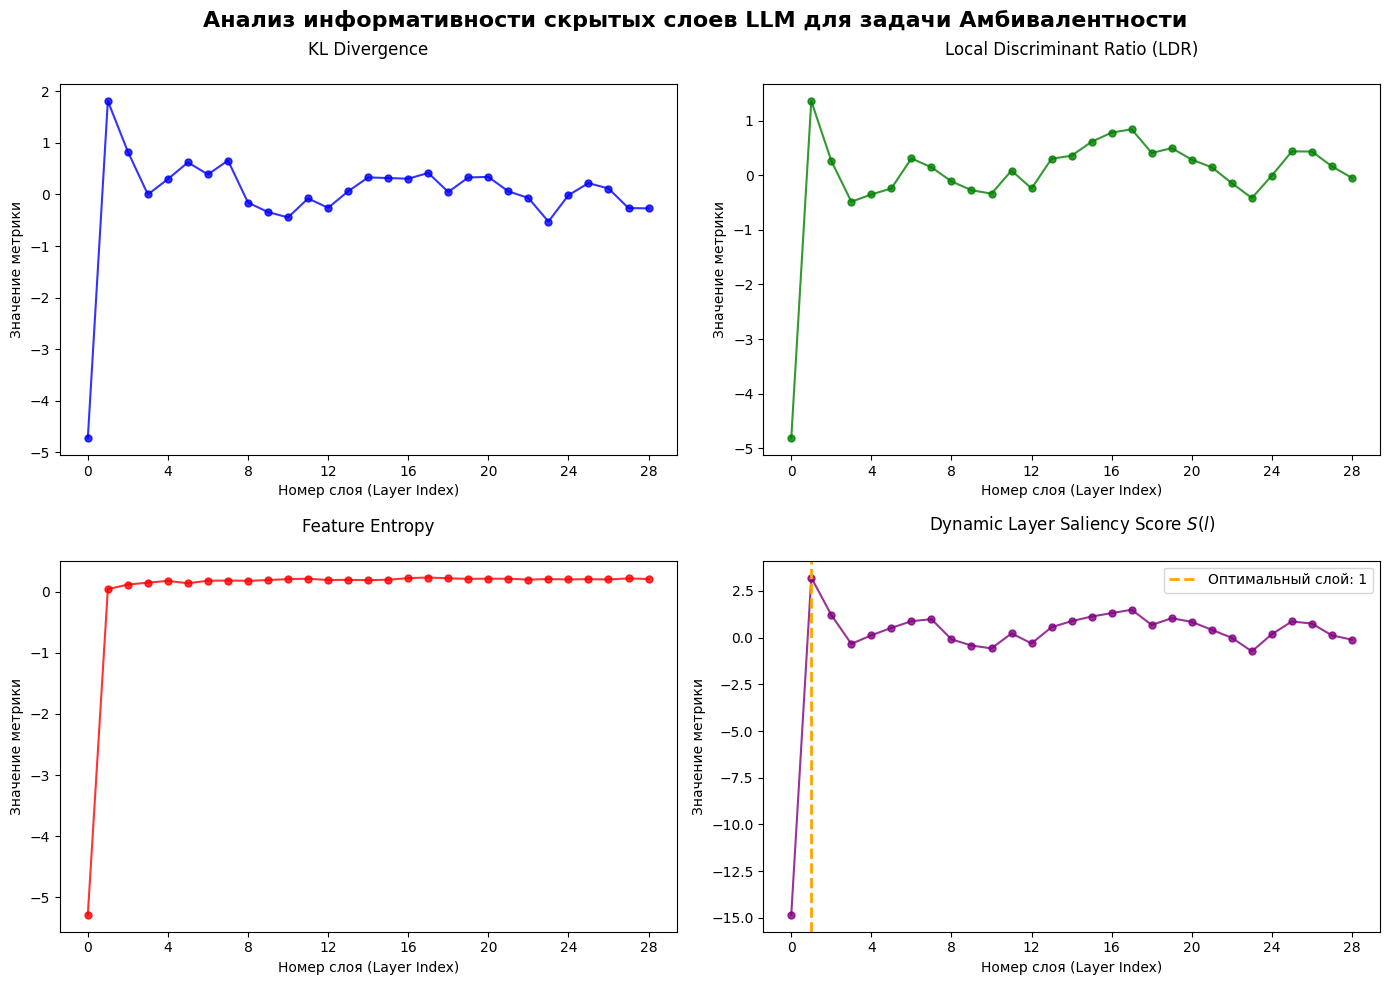

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ информативности скрытых слоев LLM для задачи Амбивалентности', fontsize=16, fontweight='bold')

metrics = [
    (norm_kl, 'KL Divergence\n', axes[0, 0], 'blue'),
    (norm_ldr, 'Local Discriminant Ratio (LDR)\n', axes[0, 1], 'green'),
    (norm_entropy, 'Feature Entropy\n', axes[1, 0], 'red'),
    (S_l, 'Dynamic Layer Saliency Score $S(l)$\n', axes[1, 1], 'purple')
]

for data, title, ax, color in metrics:
    ax.plot(np.arange(num_layers), data, marker='o', markersize=5, linestyle='-', color=color, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Номер слоя (Layer Index)')
    ax.set_ylabel('Значение метрики')
    ax.set_xticks(np.arange(0, num_layers, 4))
    if "Saliency Score" in title:
        ax.axvline(x=optimal_layer, color='orange', linestyle='--', linewidth=2, label=f'Оптимальный слой: {optimal_layer}')
        ax.legend()

plt.tight_layout()
plt.show()

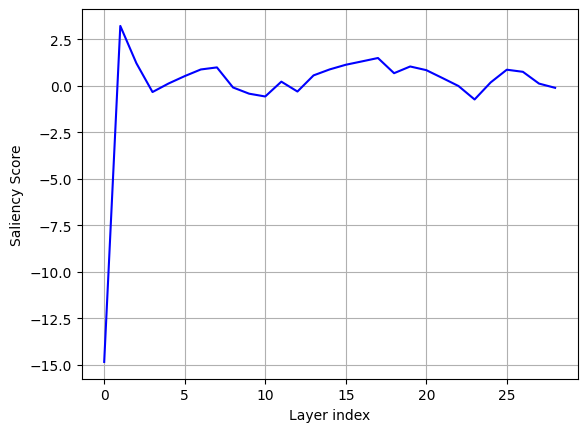

In [ ]:
plt.plot(S_l, label='Saliency Score', color='blue')
plt.xlabel('Layer index')
plt.ylabel('Saliency Score')
plt.grid()

In [ ]:
X_train_layer1 = all_features[:, top_k_layers[0], :]
X_train_layer16 = all_features[:, top_k_layers[1], :]
X_train_layer17 = all_features[:, top_k_layers[2], :]
X_train_layer26 = all_features[:, 26, :]

y_train = np.array(labels)

scorer_layer1 = LogisticRegression(solver='lbfgs', max_iter=1000)
scorer_layer16 = LogisticRegression(solver='lbfgs', max_iter=1000)
scorer_layer17 = LogisticRegression(solver='lbfgs', max_iter=1000)
scorer_layer26 = LogisticRegression(solver='lbfgs', max_iter=1000)

for scorer, X_train in zip([scorer_layer1, scorer_layer16, scorer_layer17, scorer_layer26], [X_train_layer1, X_train_layer16, X_train_layer17, X_train_layer26]):
    scorer.fit(X_train, y_train)

In [ ]:
y_pred = scorer_layer1.predict(X_train_layer1)
accuracy_score(y_train, y_pred)

0.8367346938775511

In [ ]:
df = pd.read_csv('dataset.csv', sep ='|')
df = df.sample(frac=1).reset_index(drop=True)
df.columns = ['text', 'label']
texts, labels = df['text'].tolist(), df['label'].tolist()
df.head()

,text,label
0,"За свою цену неплохо, но есть недостатки.",1
1,"Фильм ужасен, даже даром смотреть не стал бы.",0
2,"Думал, будет лучше, но в принципе терпимо.",1
3,"Отношения как качели: то хорошо, то плохо.",1
4,"Музыка ненавязчивая, можно разговаривать.",0


In [ ]:
all_features = np.zeros((len(texts), num_layers, hidden_size))

model.eval()
with torch.no_grad():
    for i, text in enumerate(texts):
        inputs = tokenizer(text, return_tensors="pt").to(model.device)
        outputs = model(**inputs,
                        max_new_tokens=32768,
                        use_cache=True,
                        return_dict_in_generate=True,
                        output_hidden_states=True)
        hidden_states = outputs.hidden_states

        for l in range(num_layers):
            last_token_vector = hidden_states[l][0, -1, :].cpu().numpy()
            all_features[i, l, :] = last_token_vector

In [ ]:
top_k_layers = list(top_k_layers)
top_k_layers.append(26)
for i, scorer in enumerate([scorer_layer1, scorer_layer16, scorer_layer17, scorer_layer26]):
    X_test = all_features[:, top_k_layers[i], :]
    y_pred = scorer.predict(X_test)
    print(f"Слой {top_k_layers[i]}")
    print(classification_report(labels, y_pred))

Слой 1
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       249
           1       0.85      0.81      0.83       250

    accuracy                           0.83       499
   macro avg       0.83      0.83      0.83       499
weighted avg       0.83      0.83      0.83       499

Слой 16
              precision    recall  f1-score   support

           0       0.55      0.99      0.71       249
           1       0.96      0.18      0.31       250

    accuracy                           0.59       499
   macro avg       0.75      0.59      0.51       499
weighted avg       0.75      0.59      0.51       499

Слой 17
              precision    recall  f1-score   support

           0       0.55      0.99      0.70       249
           1       0.96      0.18      0.30       250

    accuracy                           0.58       499
   macro avg       0.75      0.58      0.50       499
weighted avg       0.75      0.58      0.50       4

Метод показал себя неоднозначно: на первом слое логрег выдал довольно хорошее качество, при этом один из финальных слоев выдал качество чуть похуже, но намного лучшее, чем у средних слоев 16 и 17. Возможно из-за того, что последний токен нес всю информацию

Теперь попробуем учитывать информацию со всего текста


In [ ]:
train_df = pd.read_csv('getoptimal.txt', sep ='|')
train_df = train_df.sample(frac=1).reset_index(drop=True)
train_df.columns = ['text', 'label']
texts, labels = train_df['text'].tolist(), train_df['label'].tolist()
train_df.head()

,text,label
0,"Телефон греется, но это почти у всех так, зато...",1
1,Новый iPhone снимает видео как профессиональна...,1
2,"Блендер мощный, измельчает в пыль, но он такой...",1
3,"На свидании он был галантен и интересен, но по...",1
4,"Работать здесь интересно, проекты амбициозные,...",1


In [ ]:
all_features_train = np.zeros((len(texts), num_layers, hidden_size))
model.eval()
for i, text in enumerate(texts):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(model.device)
    attention_mask = inputs['attention_mask']
    with torch.no_grad():
        outputs = model(**inputs, use_cache=True,
                        return_dict_in_generate=True,
                        output_hidden_states=True)
        hidden_states = outputs.hidden_states
        for l in range(num_layers):
            token_embeddings = hidden_states[l]
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            mean_pooled_vector = (sum_embeddings / sum_mask).cpu().numpy()[0]

            all_features_train[i, l, :] = mean_pooled_vector

In [ ]:
epsilon = 1e-8

kl_scores = []
ldr_scores = []
entropy_scores = []

for l in range(num_layers):
    h_norm = features_normal[:, l, :]
    h_anom = features_anom[:, l, :]
    h_all = all_features_train[:, l, :]

    mu_norm = np.mean(h_norm, axis=0)
    var_norm = np.var(h_norm, axis=0) + epsilon

    mu_anom = np.mean(h_anom, axis=0)
    var_anom = np.var(h_anom, axis=0) + epsilon

    kl_d = 0.5 * (np.log(var_norm / var_anom) +
                  (var_anom + (mu_anom - mu_norm)**2) / var_norm - 1)
    kl_score = np.mean(kl_d)
    kl_scores.append(kl_score)

    ldr_d = ((mu_norm - mu_anom)**2) / (var_norm + var_anom + epsilon)
    ldr_score = np.mean(ldr_d)
    ldr_scores.append(ldr_score)

    B = 20
    entropy_d = []
    for d in range(hidden_size):
        counts, _ = np.histogram(h_all[:, d], bins=B, density=False)
        probs = counts / np.sum(counts)
        probs = probs[probs > 0]
        ent = -np.sum(probs * np.log2(probs))
        entropy_d.append(ent)

    entropy_score = np.mean(entropy_d)
    entropy_scores.append(entropy_score)

kl_scores = np.array(kl_scores)
ldr_scores = np.array(ldr_scores)
entropy_scores = np.array(entropy_scores)

In [ ]:
norm_kl = zscore(kl_scores)
norm_ldr = zscore(ldr_scores)
norm_entropy = zscore(entropy_scores)


S_l = norm_kl + norm_ldr + norm_entropy
optimal_layer = np.argmax(S_l)

k = 3
top_k_layers = np.sort(np.argpartition(S_l, -k)[-k:])

print(f"Топ 3 оптимальных слоя для задачи амбивалентности: {top_k_layers} из {num_layers - 1}")

Топ 3 оптимальных слоя для задачи амбивалентности: [ 1 17 20] из 28


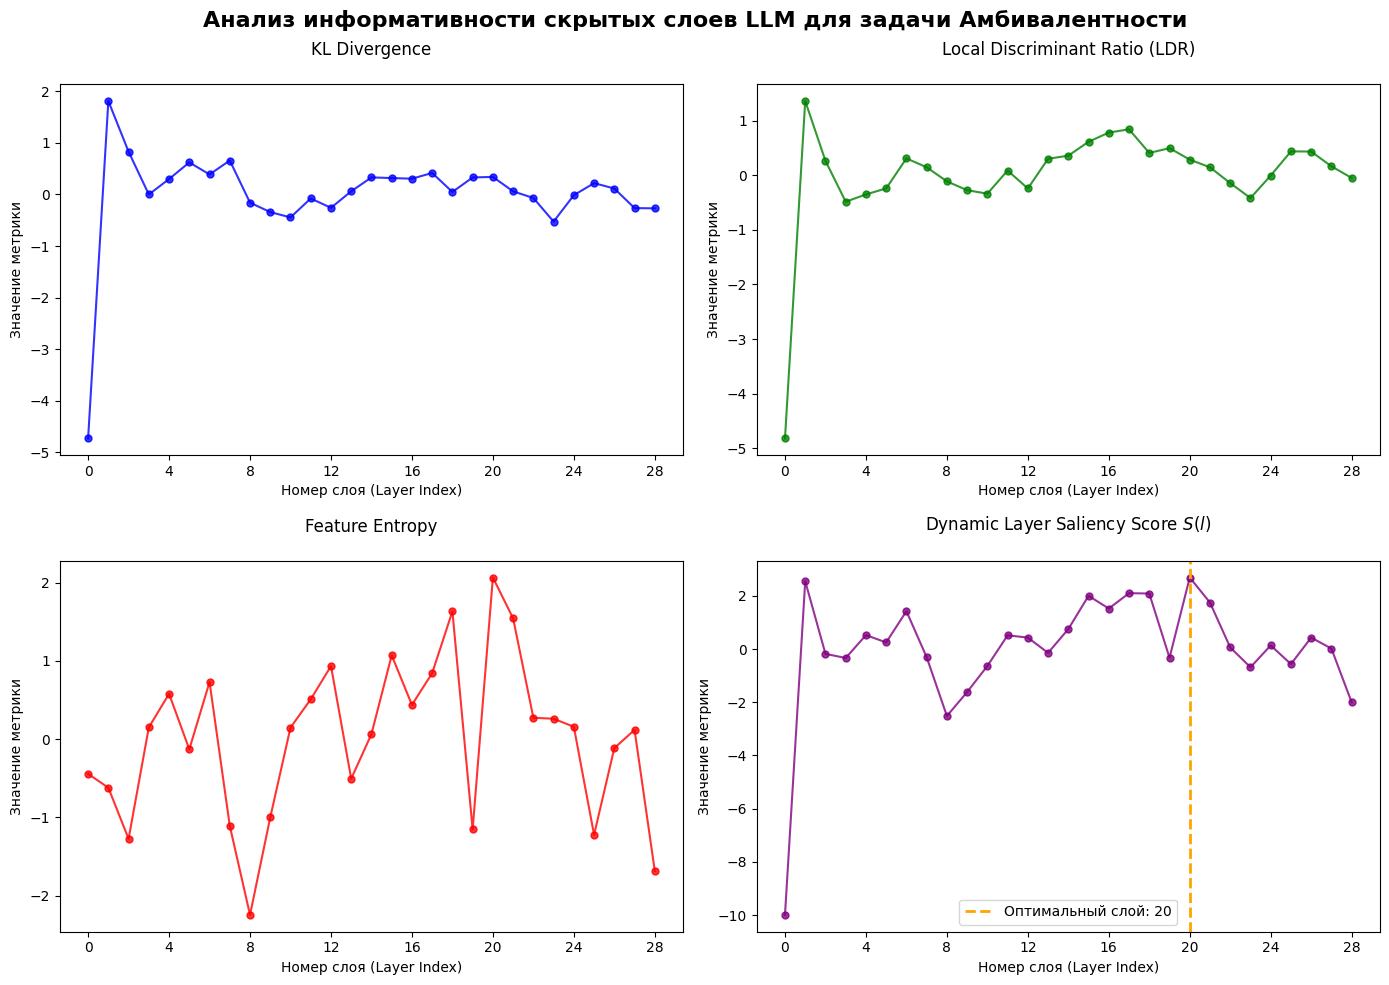

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ информативности скрытых слоев LLM для задачи Амбивалентности', fontsize=16, fontweight='bold')

metrics = [
    (norm_kl, 'KL Divergence\n', axes[0, 0], 'blue'),
    (norm_ldr, 'Local Discriminant Ratio (LDR)\n', axes[0, 1], 'green'),
    (norm_entropy, 'Feature Entropy\n', axes[1, 0], 'red'),
    (S_l, 'Dynamic Layer Saliency Score $S(l)$\n', axes[1, 1], 'purple')
]

for data, title, ax, color in metrics:
    ax.plot(np.arange(num_layers), data, marker='o', markersize=5, linestyle='-', color=color, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Layer Index')
    ax.set_ylabel('Значение метрики')
    ax.set_xticks(np.arange(0, num_layers, 4))
    if "Saliency Score" in title:
        ax.axvline(x=optimal_layer, color='orange', linestyle='--', linewidth=2, label=f'Оптимальный слой: {optimal_layer}')
        ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
scorers = []
scalers = []
top_k_layers = np.concatenate((top_k_layers, [26]))
for i in range(len(top_k_layers)):
    scaler = StandardScaler()
    scorer = LogisticRegression(solver='lbfgs', max_iter=1000, C=0.05)
    X_train = all_features_train[:, top_k_layers[i], :]
    X_train_scaled = scaler.fit_transform(X_train)
    scalers.append(scaler)
    scorer.fit(X_train_scaled, labels)
    scorers.append(scorer)

In [ ]:
df_test = pd.read_csv('dataset.csv', sep ='|')
df_test.columns = ['text', 'label']
texts, labels = df_test['text'].tolist(), df_test['label'].tolist()
df_test.head()

,text,label
0,"Обалденный фильм, давно такого не видел.",0
1,"Актеры играют великолепно, сюжет держит в напр...",0
2,"Лучшая комедия года, от души посмеялся.",0
3,Шедевр! Советую всем без исключения.,0
4,"Отличный экшн, спецэффекты на высоте.",0


In [ ]:
all_features_test = np.zeros((len(texts), num_layers, hidden_size))
model.eval()
for i, text in enumerate(texts):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(model.device)
    attention_mask = inputs['attention_mask']
    with torch.no_grad():
        outputs = model(**inputs, use_cache=True,
                        return_dict_in_generate=True,
                        output_hidden_states=True)
        hidden_states = outputs.hidden_states
        for l in range(num_layers):
            token_embeddings = hidden_states[l]

            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)

            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)

            mean_pooled_vector = (sum_embeddings / sum_mask).cpu().numpy()[0]

            all_features_test[i, l, :] = mean_pooled_vector

In [ ]:
for i in range(len(top_k_layers)):
    X_test = all_features_test[:, top_k_layers[i], :]
    scorer = scorers[i]
    scaler = scalers[i]
    X_test_scaled = scaler.transform(X_test)
    y_pred = scorer.predict(X_test_scaled)
    print(f"Слой {top_k_layers[i]}")
    print(classification_report(labels, y_pred))

Слой 1
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       249
           1       0.77      0.88      0.82       250

    accuracy                           0.81       499
   macro avg       0.82      0.81      0.81       499
weighted avg       0.82      0.81      0.81       499

Слой 17
              precision    recall  f1-score   support

           0       0.59      1.00      0.74       249
           1       1.00      0.30      0.46       250

    accuracy                           0.65       499
   macro avg       0.79      0.65      0.60       499
weighted avg       0.79      0.65      0.60       499

Слой 20
              precision    recall  f1-score   support

           0       0.70      0.97      0.81       249
           1       0.95      0.58      0.72       250

    accuracy                           0.78       499
   macro avg       0.82      0.78      0.77       499
weighted avg       0.82      0.78      0.77       4

Первый слой все еще обладает преимуществом перед более высокими слоями, хотя последние слои теперь не такие уж и плохие. Думаю, это связано с тем, что данные довольно простые (в сомнительных классах есть ключевое "но", которое, видимо, сильно решает )